# IT2011 – Breast Cancer Wisconsin (Original)

## Member 05 – PCA / Dimensionality Reduction

### Main Focus
- Principal Component Analysis (PCA)
- Dimensionality Reduction
- Explained Variance
- PCA Component Selection
- PCA Loadings

### Dataset
UCI Breast Cancer Wisconsin (Original)

In [28]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [29]:
# ============================================
# STEP 2 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [30]:
# ============================================
# STEP 3 - Load the raw dataset
# ============================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
df = pd.read_csv(url, header=None)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (699, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [31]:
# ============================================
# STEP 4 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

df.head()

,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [32]:
# ============================================
# STEP 5 - Replace '?' with NaN
# ============================================

df = df.replace("?", np.nan)

print("Missing values:")
print(df.isnull().sum())

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [33]:
# ============================================
# STEP 6 - Convert Bare_Nuclei to numeric
# ============================================

df["Bare_Nuclei"] = pd.to_numeric(
    df["Bare_Nuclei"],
    errors="coerce"
)

print(df.dtypes)

Sample_ID                        int64
Clump_Thickness                  int64
Uniformity_Cell_Size             int64
Uniformity_Cell_Shape            int64
Marginal_Adhesion                int64
Single_Epithelial_Cell_Size      int64
Bare_Nuclei                    float64
Bland_Chromatin                  int64
Normal_Nucleoli                  int64
Mitoses                          int64
Class                            int64
dtype: object


In [34]:
# ============================================
# STEP 7 - Define the predictor features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

X = df[feature_columns].copy()

print("Number of features:", len(feature_columns))
print("Feature matrix shape:", X.shape)

Number of features: 9
Feature matrix shape: (699, 9)


In [35]:
# ============================================
# STEP 8 - Prepare complete observations for PCA
# ============================================

X_pca_input = X.dropna().copy()

print("Original feature matrix shape:", X.shape)
print("PCA input shape:", X_pca_input.shape)
print("Missing values in PCA input:")
print(X_pca_input.isnull().sum().sum())

Original feature matrix shape: (699, 9)
PCA input shape: (683, 9)
Missing values in PCA input:
0


## What is Dimensionality Reduction?

Dimensionality reduction means reducing the number of input variables while trying to preserve the most important information.

The original dataset contains 9 predictive features.

PCA can transform these 9 features into a smaller number of new variables called Principal Components.

For example:

9 original features
        ↓
      PCA
        ↓
4 principal components

The new principal components are combinations of the original features.

## Why Use PCA?

The EDA showed strong correlations between several features.

For example:

- Uniformity_Cell_Size and Uniformity_Cell_Shape have a strong positive correlation.
- Several other features also contain overlapping information.

PCA can combine correlated information into a smaller number of principal components.

This can:

- Reduce the number of dimensions.
- Reduce redundancy.
- Make the dataset easier to visualize.
- Produce a more compact representation of the features.

PCA does not automatically mean that the discarded components contain no information.
They simply explain less variance than the retained components.

In [36]:
# ============================================
# STEP 11 - Standardize features before PCA
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_pca_input)

print("Scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Scaling completed.
Scaled data shape: (683, 9)


In [37]:
# ============================================
# STEP 12 - Apply PCA to all components
# ============================================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA completed.")
print("PCA data shape:", X_pca.shape)

PCA completed.
PCA data shape: (683, 9)


In [38]:
# ============================================
# STEP 13 - Calculate explained variance ratio
# ============================================

explained_variance = pca.explained_variance_ratio_

explained_variance_df = pd.DataFrame({
    "Component": [
        f"PC{i+1}" for i in range(len(explained_variance))
    ],
    "Explained_Variance_Ratio": explained_variance,
    "Explained_Variance_Percentage": explained_variance * 100
})

explained_variance_df

,Component,Explained_Variance_Ratio,Explained_Variance_Percentage
0,PC1,0.655500,65.549993
1,PC2,0.086216,8.621632
2,PC3,0.059917,5.991692
3,PC4,0.051070,5.106972
4,PC5,0.042253,4.225287
5,PC6,0.033542,3.354183
6,PC7,0.032711,3.271141
7,PC8,0.028971,2.897065
8,PC9,0.009820,0.982036


In [39]:
# ============================================
# STEP 14 - Calculate cumulative explained variance
# ============================================

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

cumulative_variance_df = pd.DataFrame({
    "Component": [
        f"PC{i+1}" for i in range(len(cumulative_variance))
    ],
    "Cumulative_Variance_Percentage":
        cumulative_variance * 100
})

cumulative_variance_df

,Component,Cumulative_Variance_Percentage
0,PC1,65.549993
1,PC2,74.171625
2,PC3,80.163316
3,PC4,85.270288
4,PC5,89.495575
5,PC6,92.849758
6,PC7,96.120899
7,PC8,99.017964
8,PC9,100.000000


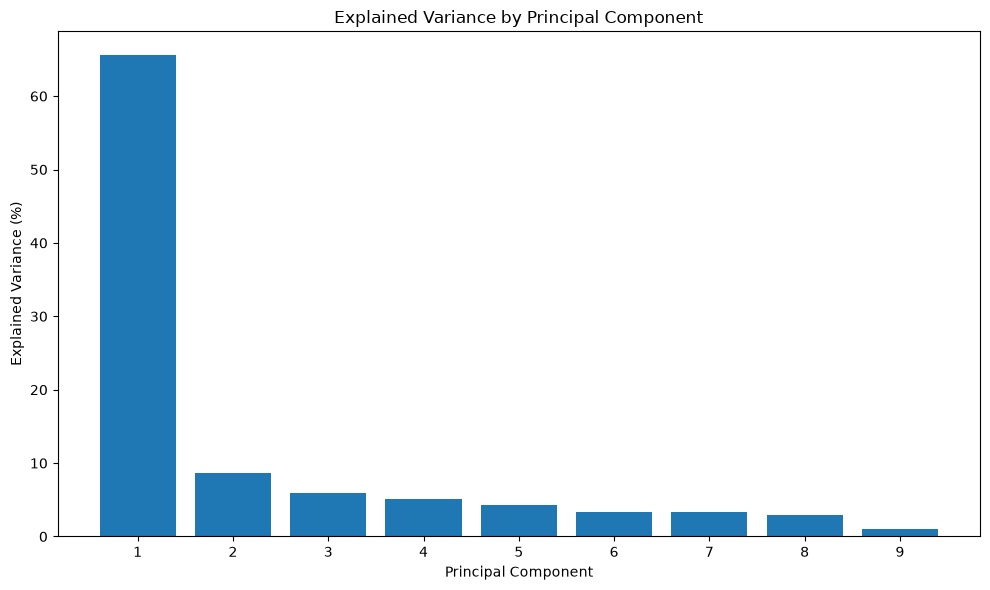

In [40]:
# ============================================
# STEP 15 - Plot explained variance
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance * 100
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Component")

plt.xticks(range(1, len(explained_variance) + 1))

plt.tight_layout()
plt.show()

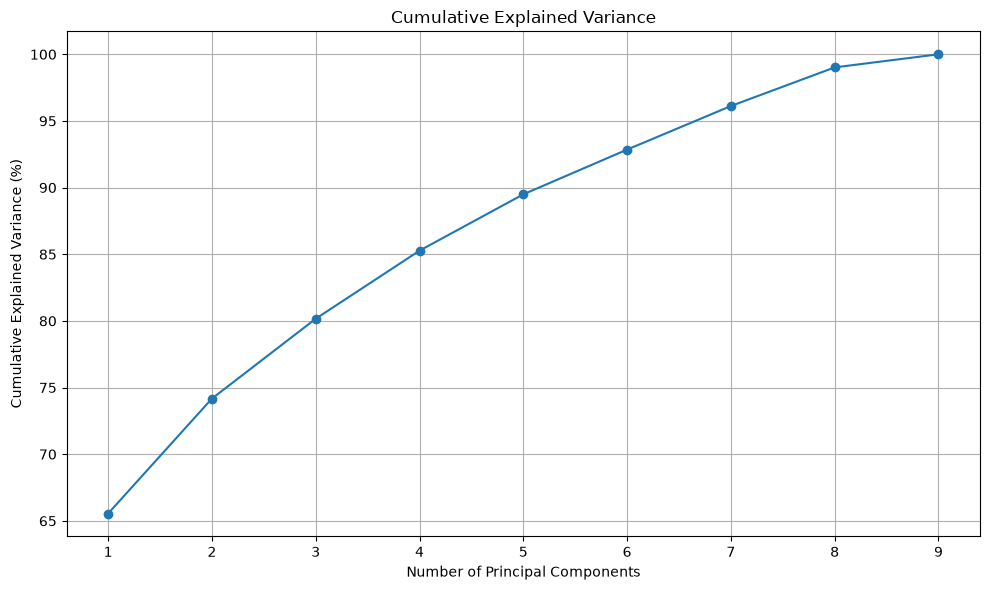

In [41]:
# ============================================
# STEP 16 - Plot cumulative explained variance
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")

plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)

plt.tight_layout()
plt.show()

## Selecting the Number of Components

The cumulative explained variance is used to understand how much information is retained as more components are included.

For this dataset:

- PC1 explains approximately 65.56%.
- PC1 + PC2 explain approximately 74.18%.
- PC1 + PC2 + PC3 explain approximately 80.18%.
- PC1 + PC2 + PC3 + PC4 explain approximately 85.35%.
- The first 5 components explain approximately 89.47%.

Four components were selected as the main PCA representation because they retain approximately 85% of the total variance while reducing the number of dimensions from 9 to 4.

This gives a balance between information retention and dimensionality reduction.

In [42]:
# ============================================
# STEP 18 - Create PCA representation with 4 components
# ============================================

pca_4 = PCA(n_components=4)

X_pca_4 = pca_4.fit_transform(X_scaled)

pca_columns = [
    "PC1",
    "PC2",
    "PC3",
    "PC4"
]

X_pca_df = pd.DataFrame(
    X_pca_4,
    columns=pca_columns,
    index=X_pca_input.index
)

print("PCA with 4 components completed.")
print("Reduced data shape:", X_pca_df.shape)

X_pca_df.head()

PCA with 4 components completed.
Reduced data shape: (683, 4)


,PC1,PC2,PC3,PC4
0,-1.470171,-0.104273,0.565685,0.031959
1,1.442046,-0.570141,-0.236601,0.478150
2,-1.592478,-0.076120,-0.048858,0.092388
3,1.479812,-0.528452,0.603048,-1.410827
4,-1.344862,-0.090719,-0.029997,0.338284


In [43]:
# ============================================
# STEP 19 - Verify variance retained by 4 components
# ============================================

variance_4_components = pca_4.explained_variance_ratio_

print("Explained variance by each component:")
for i, variance in enumerate(variance_4_components, start=1):
    print(f"PC{i}: {variance * 100:.2f}%")

print(
    "\nTotal variance retained by 4 components:",
    f"{variance_4_components.sum() * 100:.2f}%"
)

Explained variance by each component:
PC1: 65.55%
PC2: 8.62%
PC3: 5.99%
PC4: 5.11%

Total variance retained by 4 components: 85.27%


In [44]:
# ============================================
# STEP 20 - Calculate PCA loadings
# ============================================

loadings = pd.DataFrame(
    pca_4.components_.T,
    columns=pca_columns,
    index=feature_columns
)

loadings

,PC1,PC2,PC3,PC4
Clump_Thickness,0.302063,-0.140801,0.866372,0.107828
Uniformity_Cell_Size,0.380793,-0.046640,-0.019938,-0.204255
Uniformity_Cell_Shape,0.377583,-0.082422,0.033511,-0.175866
Marginal_Adhesion,0.332724,-0.052094,-0.412647,0.493173
Single_Epithelial_Cell_Size,0.336234,0.164404,-0.087743,-0.427384
Bare_Nuclei,0.335068,-0.261261,0.000691,0.498618
Bland_Chromatin,0.345747,-0.228077,-0.213072,0.013047
Normal_Nucleoli,0.335591,0.033966,-0.134248,-0.417113
Mitoses,0.230206,0.905557,0.080492,0.258988


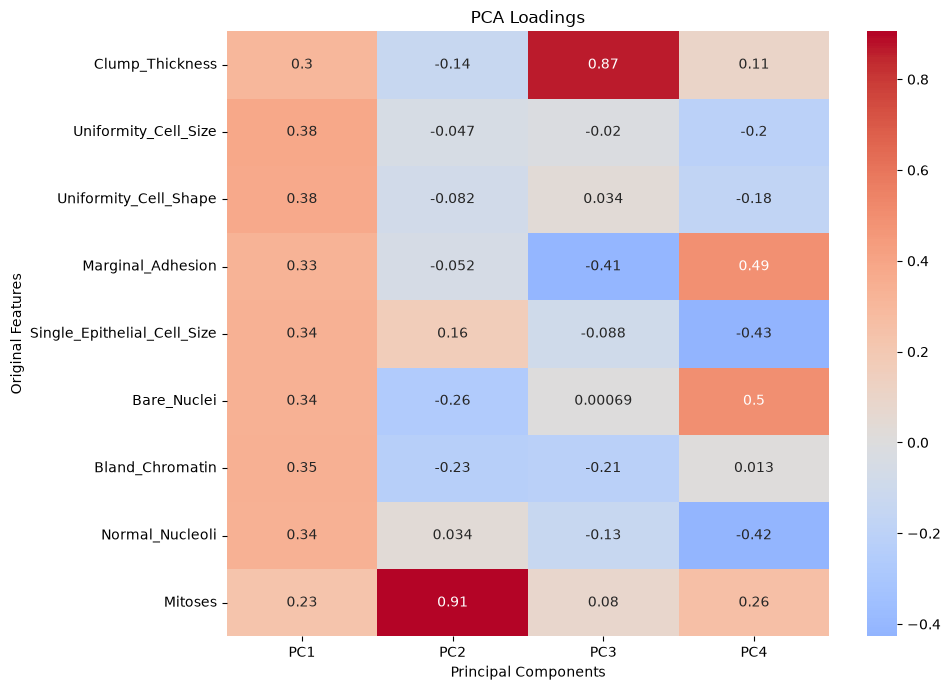

In [45]:
# ============================================
# STEP 21 - Visualize PCA loadings
# ============================================

plt.figure(figsize=(10, 7))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")

plt.tight_layout()
plt.show()

In [46]:
# ============================================
# STEP 22 - Save explained variance results
# ============================================

variance_path = "results/outputs/pca_explained_variance.csv"

explained_variance_df.to_csv(
    variance_path,
    index=False
)

print("Explained variance saved to:")
print(variance_path)

Explained variance saved to:
results/outputs/pca_explained_variance.csv


In [47]:
# ============================================
# STEP 23 - Save cumulative explained variance
# ============================================

cumulative_path = "results/outputs/pca_cumulative_variance.csv"

cumulative_variance_df.to_csv(
    cumulative_path,
    index=False
)

print("Cumulative variance saved to:")
print(cumulative_path)

Cumulative variance saved to:
results/outputs/pca_cumulative_variance.csv


In [48]:
# ============================================
# STEP 24 - Save PCA reduced dataset
# ============================================

pca_data_path = "results/outputs/pca_4_components.csv"

X_pca_df.to_csv(
    pca_data_path,
    index=False
)

print("PCA reduced dataset saved to:")
print(pca_data_path)

PCA reduced dataset saved to:
results/outputs/pca_4_components.csv


In [49]:
# ============================================
# STEP 25 - Save PCA loadings
# ============================================

loadings_path = "results/outputs/pca_loadings.csv"

loadings.to_csv(
    loadings_path
)

print("PCA loadings saved to:")
print(loadings_path)

PCA loadings saved to:
results/outputs/pca_loadings.csv


# PCA / Dimensionality Reduction Summary

## What Was Done?

1. Loaded the Breast Cancer Wisconsin dataset.
2. Replaced `?` with NaN.
3. Converted `Bare_Nuclei` to numeric.
4. Selected the 9 predictor features.
5. Prepared complete observations for the PCA demonstration.
6. Standardized the features using StandardScaler.
7. Applied PCA to all 9 components.
8. Calculated explained variance for each component.
9. Calculated cumulative explained variance.
10. Visualized explained variance.
11. Visualized cumulative explained variance.
12. Selected 4 principal components.
13. Created a reduced dataset containing PC1–PC4.
14. Examined PCA loadings.
15. Saved PCA results and outputs.

## Main Finding

PCA reduced the dimensionality of the dataset from 9 original features to 4 principal components while retaining approximately 85% of the total variance.

This provides a more compact representation of the original features.

## Important Note

PCA components are combinations of the original features and do not have the same direct meaning as the original medical features.

For final machine learning, missing-value imputation, scaling, and PCA should be placed inside a Pipeline and fitted using the training data to prevent data leakage.

In [50]:
# ============================================
# SAVE PCA VISUALIZATION
# ============================================

plt.savefig(
    "results/eda_visualizations/explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [51]:
# ============================================
# SAVE CUMULATIVE PCA VISUALIZATION
# ============================================

plt.savefig(
    "results/eda_visualizations/cumulative_explained_variance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Final Evaluation – Individual Model

## Member 05 – PCA + Logistic Regression Classification

### Objective

The objective of this section is to combine Principal Component Analysis
(PCA) with Logistic Regression to classify breast cancer cases as:

- 0 = Benign
- 1 = Malignant

PCA is a dimensionality-reduction technique that transforms the original
predictors into a smaller set of uncorrelated principal components while
preserving as much variance as possible.

Member 05 previously investigated PCA as part of the preprocessing stage.

For the final individual model, PCA is combined with Logistic Regression
inside a machine-learning pipeline.

The pipeline will follow:

**Median Imputation → StandardScaler → PCA → Logistic Regression**

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Recall is particularly important because a false negative represents a
malignant case incorrectly classified as benign.

In [52]:
# ============================================================
# IMPORT LIBRARIES FOR PCA + LOGISTIC REGRESSION
# ============================================================

# NumPy is used for numerical operations.
import numpy as np

# Pandas is used for DataFrames and result tables.
import pandas as pd

# Matplotlib is used for visualizations.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# MODEL SELECTION TOOLS
# ------------------------------------------------------------

# train_test_split:
# Divides the dataset into training and testing sets.
#
# StratifiedKFold:
# Preserves approximately the same class proportions
# across cross-validation folds.
#
# cross_validate:
# Evaluates the model using multiple metrics.
#
# GridSearchCV:
# Tests multiple PCA and Logistic Regression configurations.
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)


# ------------------------------------------------------------
# PREPROCESSING
# ------------------------------------------------------------

# Pipeline combines preprocessing and modelling steps.
from sklearn.pipeline import Pipeline

# SimpleImputer handles missing feature values.
from sklearn.impute import SimpleImputer

# StandardScaler standardizes features before PCA.
from sklearn.preprocessing import StandardScaler

# PCA performs dimensionality reduction.
from sklearn.decomposition import PCA


# ------------------------------------------------------------
# CLASSIFICATION MODEL
# ------------------------------------------------------------

# Logistic Regression performs binary classification
# using the PCA-transformed features.
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# EVALUATION METRICS
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


print(
    "PCA + Logistic Regression libraries imported successfully."
)

PCA + Logistic Regression libraries imported successfully.


In [53]:
# ============================================================
# CHECK DATAFRAMES AVAILABLE IN MEMBER 05 NOTEBOOK
# ============================================================

# Search the current notebook session for pandas DataFrames.
print("DataFrames currently available:")
print("-" * 55)


for variable_name, variable_value in globals().items():

    # Only display pandas DataFrame variables.
    if isinstance(variable_value, pd.DataFrame):

        # Display the variable name and its dimensions.
        print(
            f"{variable_name:30s} -> "
            f"shape = {variable_value.shape}"
        )

DataFrames currently available:
-------------------------------------------------------
_                              -> shape = (9, 4)
__                             -> shape = (5, 4)
___                            -> shape = (9, 2)
df                             -> shape = (699, 11)
_3                             -> shape = (5, 11)
_4                             -> shape = (5, 11)
X                              -> shape = (699, 9)
X_pca_input                    -> shape = (683, 9)
explained_variance_df          -> shape = (9, 3)
_11                            -> shape = (9, 3)
cumulative_variance_df         -> shape = (9, 2)
_12                            -> shape = (9, 2)
X_pca_df                       -> shape = (683, 4)
_15                            -> shape = (5, 4)
loadings                       -> shape = (9, 4)
_17                            -> shape = (9, 4)
_30                            -> shape = (5, 11)
_31                            -> shape = (5, 11)
_38              

In [55]:
# ============================================================
# CHECK MEMBER 05'S ORIGINAL DATASET
# ============================================================

# Display the dimensions of the current dataframe.
print(
    "Current df shape:",
    df.shape
)


# Display all columns.
print("\nColumns:")

print(
    df.columns.tolist()
)


# Display original class distribution.
print("\nClass distribution:")

print(
    df["Class"]
    .value_counts()
    .sort_index()
)


# Count exact duplicate observations.
print("\nExact duplicate rows:")

print(
    df.duplicated().sum()
)


# Check missing values.
print("\nMissing values:")

print(
    df.isna().sum()
)

Current df shape: (699, 11)

Columns:
['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

Class distribution:
Class
2    458
4    241
Name: count, dtype: int64

Exact duplicate rows:
8

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [56]:
# ============================================================
# CREATE CLEAN DATA FOR FINAL PCA + LOGISTIC REGRESSION MODEL
# ============================================================

# Create a separate copy of the original dataframe.
#
# This keeps Member 05's original PCA implementation unchanged.
model_df = df.copy()


# Remove the 8 exact duplicate observations.
#
# We retain the first occurrence of each observation.
model_df = model_df.drop_duplicates(
    keep="first"
).reset_index(drop=True)


# Display the final dataset dimensions.
print(
    "Final modelling dataset shape:",
    model_df.shape
)


# Confirm that no exact duplicate observations remain.
print(
    "Remaining duplicate rows:",
    model_df.duplicated().sum()
)


# Display the class distribution after duplicate removal.
print("\nClass distribution:")

print(
    model_df["Class"]
    .value_counts()
    .sort_index()
)


# Check missing values.
#
# Bare_Nuclei should still contain missing values because
# imputation will be performed later inside the pipeline.
print("\nMissing values:")

print(
    model_df.isna().sum()
)

Final modelling dataset shape: (691, 11)
Remaining duplicate rows: 0

Class distribution:
Class
2    453
4    238
Name: count, dtype: int64

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [57]:
# ============================================================
# CREATE FEATURES AND TARGET FOR FINAL MODELLING
# ============================================================

# Create the feature matrix using the nine predictive
# attributes.
#
# Sample_ID is removed because it is only an identifier.
# Class is removed because it is the target variable.
X = model_df.drop(
    columns=[
        "Sample_ID",
        "Class"
    ]
).copy()


# Convert the original class labels into binary labels:
#
# 2 = Benign    -> 0
# 4 = Malignant -> 1
y = model_df["Class"].map({
    2: 0,
    4: 1
})


# Display dimensions.
print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)


# Display target distribution.
print("\nTarget distribution:")

print(
    y.value_counts()
    .sort_index()
)


# Confirm that target encoding was successful.
print(
    "\nMissing target values:",
    y.isna().sum()
)


# Display the nine predictors.
print("\nFeatures used:")

print(
    X.columns.tolist()
)

X shape: (691, 9)
y shape: (691,)

Target distribution:
Class
0    453
1    238
Name: count, dtype: int64

Missing target values: 0

Features used:
['Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']


In [58]:
# ============================================================
# CREATE TRAINING AND TESTING DATASETS
# ============================================================

# Split the dataset into:
#
# 80% training data
# 20% testing data
#
# random_state=42 ensures reproducibility.
#
# stratify=y preserves approximately the same benign/malignant
# class ratio in both training and testing datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# VERIFY THE DATA SPLIT
# ============================================================

print(
    "Full dataset :",
    len(X)
)

print(
    "Training set :",
    X_train.shape
)

print(
    "Testing set  :",
    X_test.shape
)


print("\nTraining target distribution:")

print(
    y_train.value_counts()
    .sort_index()
)


print("\nTesting target distribution:")

print(
    y_test.value_counts()
    .sort_index()
)


# Confirm that no observations were lost.
print(
    "\nTrain + Test :",
    len(X_train) + len(X_test)
)

Full dataset : 691
Training set : (552, 9)
Testing set  : (139, 9)

Training target distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing target distribution:
Class
0    91
1    48
Name: count, dtype: int64

Train + Test : 691


## PCA Within the Final Modelling Pipeline

Member 05 previously investigated Principal Component Analysis (PCA) as a
dimensionality-reduction technique.

For the final model evaluation, PCA is placed inside the machine-learning
Pipeline rather than being fitted to the complete dataset before the
train-test split.

The final pipeline follows:

**Median Imputation → StandardScaler → PCA → Logistic Regression**

This order is important:

1. Missing values are replaced using the median calculated from training data.
2. StandardScaler standardizes the predictors because PCA is affected by
   feature scale.
3. PCA learns the principal components from the training data.
4. Logistic Regression uses the resulting principal components for
   classification.

Keeping these preprocessing operations inside the Pipeline helps prevent
information from the held-out test dataset from influencing preprocessing
or dimensionality reduction.

In [59]:
# ============================================================
# CREATE BASELINE PCA + LOGISTIC REGRESSION PIPELINE
# ============================================================

# Create a complete machine-learning pipeline.
#
# The pipeline performs:
#
# 1. Median imputation
# 2. Standardization
# 3. PCA dimensionality reduction
# 4. Logistic Regression classification
pca_lr_pipeline = Pipeline([

    # --------------------------------------------------------
    # STEP 1: MISSING-VALUE IMPUTATION
    # --------------------------------------------------------

    # Replace missing predictor values using medians learned
    # only from the training data.
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),


    # --------------------------------------------------------
    # STEP 2: FEATURE SCALING
    # --------------------------------------------------------

    # Standardize the nine original predictors before PCA.
    (
        "scaler",
        StandardScaler()
    ),


    # --------------------------------------------------------
    # STEP 3: PCA
    # --------------------------------------------------------

    # Reduce the nine standardized predictors to four
    # principal components.
    (
        "pca",
        PCA(
            n_components=4
        )
    ),


    # --------------------------------------------------------
    # STEP 4: LOGISTIC REGRESSION
    # --------------------------------------------------------

    # Use the principal components to perform binary
    # classification.
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])


# ============================================================
# TRAIN BASELINE MODEL
# ============================================================

# Fit all preprocessing steps and the classifier using
# only the training dataset.
pca_lr_pipeline.fit(
    X_train,
    y_train
)


print(
    "Baseline PCA + Logistic Regression trained successfully."
)

Baseline PCA + Logistic Regression trained successfully.


In [60]:
# ============================================================
# CHECK PCA EXPLAINED VARIANCE
# ============================================================

# Access the PCA object after it has been fitted using
# the training dataset.
fitted_baseline_pca = pca_lr_pipeline.named_steps[
    "pca"
]


# Get the percentage of variance explained by each
# principal component.
baseline_pca_variance = (
    fitted_baseline_pca.explained_variance_ratio_
)


# Calculate cumulative explained variance.
baseline_pca_cumulative_variance = np.cumsum(
    baseline_pca_variance
)


print(
    "Baseline PCA Explained Variance"
)

print("-" * 45)


# Display the variance explained by each component.
for component_number, variance in enumerate(
    baseline_pca_variance,
    start=1
):

    print(
        f"PC{component_number}: "
        f"{variance * 100:.2f}%"
    )


# Display the total variance retained by all four components.
print(
    "\nTotal variance explained by 4 components:",
    f"{baseline_pca_cumulative_variance[-1] * 100:.2f}%"
)

Baseline PCA Explained Variance
---------------------------------------------
PC1: 65.67%
PC2: 8.52%
PC3: 6.05%
PC4: 5.30%

Total variance explained by 4 components: 85.55%


In [61]:
# ============================================================
# BASELINE PCA + LOGISTIC REGRESSION PREDICTIONS
# ============================================================

# Predict the class labels for the held-out test dataset.
y_pred_pca_lr_baseline = pca_lr_pipeline.predict(
    X_test
)


# Obtain malignant-class probabilities for ROC-AUC.
y_prob_pca_lr_baseline = (
    pca_lr_pipeline.predict_proba(
        X_test
    )[:, 1]
)


# ============================================================
# CALCULATE BASELINE TEST METRICS
# ============================================================

pca_lr_baseline_accuracy = accuracy_score(
    y_test,
    y_pred_pca_lr_baseline
)

pca_lr_baseline_precision = precision_score(
    y_test,
    y_pred_pca_lr_baseline
)

pca_lr_baseline_recall = recall_score(
    y_test,
    y_pred_pca_lr_baseline
)

pca_lr_baseline_f1 = f1_score(
    y_test,
    y_pred_pca_lr_baseline
)

pca_lr_baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_pca_lr_baseline
)


# ============================================================
# DISPLAY BASELINE TEST RESULTS
# ============================================================

print(
    "Baseline PCA + Logistic Regression Test Results"
)

print("-" * 55)

print(
    f"Accuracy  : {pca_lr_baseline_accuracy:.4f}"
)

print(
    f"Precision : {pca_lr_baseline_precision:.4f}"
)

print(
    f"Recall    : {pca_lr_baseline_recall:.4f}"
)

print(
    f"F1-score  : {pca_lr_baseline_f1:.4f}"
)

print(
    f"ROC-AUC   : {pca_lr_baseline_roc_auc:.4f}"
)

Baseline PCA + Logistic Regression Test Results
-------------------------------------------------------
Accuracy  : 0.9784
Precision : 0.9787
Recall    : 0.9583
F1-score  : 0.9684
ROC-AUC   : 0.9966


In [62]:
# ============================================================
# BASELINE PCA + LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
pca_lr_baseline_cm = confusion_matrix(
    y_test,
    y_pred_pca_lr_baseline
)


print(
    "Baseline PCA + Logistic Regression "
    "Confusion Matrix:"
)

print(
    pca_lr_baseline_cm
)


# Extract individual values.
tn_pca_lr, fp_pca_lr, fn_pca_lr, tp_pca_lr = (
    pca_lr_baseline_cm.ravel()
)


print("\nConfusion Matrix Details")
print("-" * 40)

print(
    "True Negatives  (TN):",
    tn_pca_lr
)

print(
    "False Positives (FP):",
    fp_pca_lr
)

print(
    "False Negatives (FN):",
    fn_pca_lr
)

print(
    "True Positives  (TP):",
    tp_pca_lr
)


# Confirm the correct test-set size.
print(
    "\nTotal test observations:",
    pca_lr_baseline_cm.sum()
)

Baseline PCA + Logistic Regression Confusion Matrix:
[[90  1]
 [ 2 46]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 90
False Positives (FP): 1
False Negatives (FN): 2
True Positives  (TP): 46

Total test observations: 139


In [63]:
# ============================================================
# CREATE STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

# Preserve class proportions across five validation folds.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Define the common evaluation metrics used by all members.
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ============================================================
# PERFORM BASELINE CROSS-VALIDATION
# ============================================================

# PCA and all preprocessing steps are fitted separately
# inside every training fold.
pca_lr_cv_results = cross_validate(
    pca_lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)


print(
    "Baseline PCA + Logistic Regression - "
    "5-Fold Cross-Validation"
)

print("-" * 65)


# Display mean ± standard deviation for each metric.
for metric in scoring.keys():

    scores = pca_lr_cv_results[
        f"test_{metric}"
    ]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Baseline PCA + Logistic Regression - 5-Fold Cross-Validation
-----------------------------------------------------------------
ACCURACY  : 0.9638 ± 0.0099
PRECISION : 0.9429 ± 0.0090
RECALL    : 0.9526 ± 0.0307
F1        : 0.9474 ± 0.0150
ROC_AUC   : 0.9948 ± 0.0024


## PCA + Logistic Regression Hyperparameter Tuning

The baseline model uses four principal components. However, the optimum
number of PCA components for classification does not necessarily have to
be the same number selected only from explained variance.

Therefore, different PCA + Logistic Regression configurations are evaluated
using GridSearchCV.

The following hyperparameters are investigated:

### PCA Hyperparameter

- **n_components** – Number of principal components retained after
  dimensionality reduction.

The following values are tested:

- 2 components
- 3 components
- 4 components
- 5 components
- 6 components
- 7 components
- 8 components
- 9 components

### Logistic Regression Hyperparameters

- **C** – Controls regularization strength. Smaller C values apply stronger
  regularization.
- **class_weight** – Tests normal class weighting and balanced class
  weighting.

All configurations are evaluated using 5-fold stratified cross-validation.

F1-score is used to select the optimum configuration because it balances
precision and recall.

This experiment allows the effect of different levels of PCA dimensionality
reduction to be evaluated rather than assuming that four components must
always provide the best classification performance.

In [64]:
# ============================================================
# PCA + LOGISTIC REGRESSION HYPERPARAMETER GRID
# ============================================================

# Test different levels of dimensionality reduction.
#
# Since the original dataset contains 9 predictive features,
# PCA can retain between 1 and 9 components.
#
# We test 2 through 9 components to compare stronger and
# weaker dimensionality reduction.
pca_lr_param_grid = {

    # Number of principal components retained.
    "pca__n_components": [
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9
    ],


    # Logistic Regression regularization strength.
    #
    # Smaller C = stronger regularization.
    # Larger C  = weaker regularization.
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],


    # Compare normal weighting with automatic
    # class balancing.
    "model__class_weight": [
        None,
        "balanced"
    ]
}


# ============================================================
# CALCULATE NUMBER OF CONFIGURATIONS
# ============================================================

# 8 PCA choices
# × 5 C values
# × 2 class-weight choices
number_of_pca_lr_combinations = (
    8 * 5 * 2
)


print(
    "PCA + Logistic Regression configurations:",
    number_of_pca_lr_combinations
)


# Each configuration is evaluated using 5 folds.
print(
    "Total model fits:",
    number_of_pca_lr_combinations * 5
)

PCA + Logistic Regression configurations: 80
Total model fits: 400


In [65]:
# ============================================================
# GRID SEARCH FOR PCA + LOGISTIC REGRESSION
# ============================================================

# Create GridSearchCV using the complete pipeline.
#
# Imputation, scaling and PCA are performed separately
# within each cross-validation fold.
pca_lr_grid_search = GridSearchCV(

    # Complete modelling pipeline.
    estimator=pca_lr_pipeline,

    # PCA and Logistic Regression parameter combinations.
    param_grid=pca_lr_param_grid,

    # Select the optimum configuration according to F1.
    scoring="f1",

    # Use stratified 5-fold cross-validation.
    cv=cv,

    # Use all available processor cores.
    n_jobs=-1,

    # Save training scores for later inspection.
    return_train_score=True,

    # Display fitting progress.
    verbose=1
)


# ============================================================
# TRAIN ALL CONFIGURATIONS
# ============================================================

# Only training data is used for GridSearchCV.
#
# The 139-row held-out test set remains untouched.
pca_lr_grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# DISPLAY OPTIMUM CONFIGURATION
# ============================================================

print(
    "\nPCA + Logistic Regression Grid Search Complete"
)

print("-" * 60)


print(
    "Best Parameters:"
)

print(
    pca_lr_grid_search.best_params_
)


print(
    "\nBest Cross-Validation F1:",
    f"{pca_lr_grid_search.best_score_:.4f}"
)

Fitting 5 folds for each of 80 candidates, totalling 400 fits

PCA + Logistic Regression Grid Search Complete
------------------------------------------------------------
Best Parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'pca__n_components': 4}

Best Cross-Validation F1: 0.9559


In [66]:
# ============================================================
# CREATE GRID SEARCH RESULTS DATAFRAME
# ============================================================

# Convert every GridSearchCV configuration and result
# into a pandas DataFrame.
pca_lr_grid_results = pd.DataFrame(
    pca_lr_grid_search.cv_results_
)


# Select the most useful columns for comparison.
pca_lr_top_results = pca_lr_grid_results[[
    "rank_test_score",
    "param_pca__n_components",
    "param_model__C",
    "param_model__class_weight",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].copy()


# Sort configurations from highest-ranked to lowest-ranked.
pca_lr_top_results = pca_lr_top_results.sort_values(
    by="rank_test_score"
)


print(
    "Top 10 PCA + Logistic Regression Configurations:"
)


display(
    pca_lr_top_results.head(10)
)

Top 10 PCA + Logistic Regression Configurations:


,rank_test_score,param_pca__n_components,param_model__C,param_model__class_weight,mean_train_score,mean_test_score,std_test_score
26,1,4,0.10,balanced,0.956634,0.955895,0.013896
10,2,4,0.01,balanced,0.955162,0.955683,0.010968
8,2,2,0.01,balanced,0.952006,0.955683,0.010968
11,2,5,0.01,balanced,0.955162,0.955683,0.010968
41,2,3,1.00,balanced,0.959281,0.955683,0.010968
54,6,8,10.00,NaN,0.953252,0.955278,0.010762
38,6,8,1.00,NaN,0.953938,0.955278,0.010762
39,6,9,1.00,NaN,0.953248,0.955278,0.010762
57,9,3,10.00,balanced,0.957987,0.953282,0.013298
73,9,3,100.00,balanced,0.957987,0.953282,0.013298


In [67]:
# ============================================================
# COMPARE PCA COMPONENT COUNTS
# ============================================================

# Calculate the highest validation F1 obtained for each
# number of principal components.
#
# This allows us to see which PCA dimensionality produced
# the strongest classification performance after tuning
# the Logistic Regression parameters.
pca_component_comparison = (
    pca_lr_grid_results
    .groupby(
        "param_pca__n_components"
    )["mean_test_score"]
    .max()
    .reset_index()
)


# Give the columns clearer names.
pca_component_comparison.columns = [
    "PCA_Components",
    "Best_CV_F1"
]


# Sort by the number of components.
pca_component_comparison = (
    pca_component_comparison
    .sort_values(
        by="PCA_Components"
    )
    .reset_index(drop=True)
)


print(
    "Best Cross-Validation F1 by PCA Component Count:"
)


display(
    pca_component_comparison.round(4)
)

Best Cross-Validation F1 by PCA Component Count:


,PCA_Components,Best_CV_F1
0,2,0.9557
1,3,0.9557
2,4,0.9559
3,5,0.9557
4,6,0.9529
5,7,0.9529
6,8,0.9553
7,9,0.9553


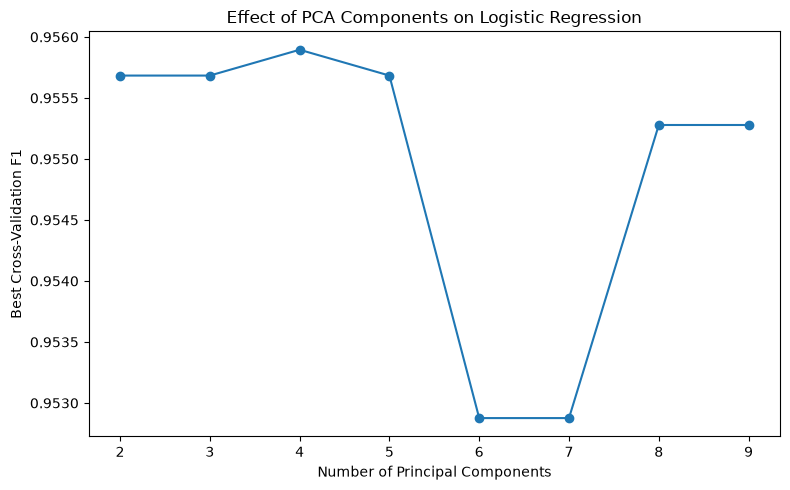

In [68]:
# ============================================================
# PLOT PCA COMPONENT COUNT VS CLASSIFICATION PERFORMANCE
# ============================================================

# Create a line plot showing how the best validation
# F1-score changes as more principal components are retained.
plt.figure(
    figsize=(8, 5)
)


plt.plot(
    pca_component_comparison[
        "PCA_Components"
    ],
    pca_component_comparison[
        "Best_CV_F1"
    ],
    marker="o"
)


# Add labels.
plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Best Cross-Validation F1"
)

plt.title(
    "Effect of PCA Components on Logistic Regression"
)


# Display each component count clearly.
plt.xticks(
    pca_component_comparison[
        "PCA_Components"
    ]
)


# Improve layout.
plt.tight_layout()


# Display the graph.
plt.show()

In [69]:
# ============================================================
# RETRIEVE THE BEST PCA + LOGISTIC REGRESSION MODEL
# ============================================================

# GridSearchCV automatically refits the best configuration
# using the complete training dataset.
#
# Therefore, best_estimator_ contains the final tuned pipeline:
#
# Median Imputation
# -> StandardScaler
# -> PCA
# -> Logistic Regression
best_pca_lr_model = (
    pca_lr_grid_search.best_estimator_
)


# Display the selected parameters.
print(
    "Selected PCA + Logistic Regression Parameters:"
)

print(
    pca_lr_grid_search.best_params_
)

Selected PCA + Logistic Regression Parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'pca__n_components': 4}


In [70]:
# ============================================================
# EXAMINE PCA IN THE TUNED MODEL
# ============================================================

# Access the fitted PCA object from the best pipeline.
tuned_pca = best_pca_lr_model.named_steps[
    "pca"
]


# Obtain the explained variance ratio for each selected
# principal component.
tuned_pca_variance = (
    tuned_pca.explained_variance_ratio_
)


# Calculate cumulative explained variance.
tuned_pca_cumulative_variance = np.cumsum(
    tuned_pca_variance
)


print(
    "Tuned Model PCA Explained Variance"
)

print("-" * 45)


# Display the variance explained by each component.
for component_number, variance in enumerate(
    tuned_pca_variance,
    start=1
):

    print(
        f"PC{component_number}: "
        f"{variance * 100:.2f}%"
    )


# Display total variance retained.
print(
    "\nTotal variance retained:",
    f"{tuned_pca_cumulative_variance[-1] * 100:.2f}%"
)

Tuned Model PCA Explained Variance
---------------------------------------------
PC1: 65.67%
PC2: 8.52%
PC3: 6.05%
PC4: 5.30%

Total variance retained: 85.55%


In [71]:
# ============================================================
# TUNED PCA + LOGISTIC REGRESSION PREDICTIONS
# ============================================================

# Predict class labels for the untouched test dataset.
y_pred_pca_lr_tuned = best_pca_lr_model.predict(
    X_test
)


# Obtain malignant-class probabilities for ROC-AUC.
y_prob_pca_lr_tuned = (
    best_pca_lr_model.predict_proba(
        X_test
    )[:, 1]
)


# ============================================================
# CALCULATE TUNED TEST METRICS
# ============================================================

pca_lr_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_pca_lr_tuned
)

pca_lr_tuned_precision = precision_score(
    y_test,
    y_pred_pca_lr_tuned
)

pca_lr_tuned_recall = recall_score(
    y_test,
    y_pred_pca_lr_tuned
)

pca_lr_tuned_f1 = f1_score(
    y_test,
    y_pred_pca_lr_tuned
)

pca_lr_tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_pca_lr_tuned
)


# ============================================================
# DISPLAY TUNED TEST RESULTS
# ============================================================

print(
    "Tuned PCA + Logistic Regression Test Results"
)

print("-" * 55)

print(
    f"Accuracy  : {pca_lr_tuned_accuracy:.4f}"
)

print(
    f"Precision : {pca_lr_tuned_precision:.4f}"
)

print(
    f"Recall    : {pca_lr_tuned_recall:.4f}"
)

print(
    f"F1-score  : {pca_lr_tuned_f1:.4f}"
)

print(
    f"ROC-AUC   : {pca_lr_tuned_roc_auc:.4f}"
)

Tuned PCA + Logistic Regression Test Results
-------------------------------------------------------
Accuracy  : 0.9712
Precision : 0.9583
Recall    : 0.9583
F1-score  : 0.9583
ROC-AUC   : 0.9970


In [72]:
# ============================================================
# TUNED PCA + LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
pca_lr_tuned_cm = confusion_matrix(
    y_test,
    y_pred_pca_lr_tuned
)


print(
    "Tuned PCA + Logistic Regression "
    "Confusion Matrix:"
)

print(
    pca_lr_tuned_cm
)


# Extract the four confusion-matrix values.
tn_tuned_pca_lr, fp_tuned_pca_lr, \
fn_tuned_pca_lr, tp_tuned_pca_lr = (
    pca_lr_tuned_cm.ravel()
)


print("\nConfusion Matrix Details")
print("-" * 40)

print(
    "True Negatives  (TN):",
    tn_tuned_pca_lr
)

print(
    "False Positives (FP):",
    fp_tuned_pca_lr
)

print(
    "False Negatives (FN):",
    fn_tuned_pca_lr
)

print(
    "True Positives  (TP):",
    tp_tuned_pca_lr
)


# Verify that the canonical test dataset is still used.
print(
    "\nTotal test observations:",
    pca_lr_tuned_cm.sum()
)

Tuned PCA + Logistic Regression Confusion Matrix:
[[89  2]
 [ 2 46]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 89
False Positives (FP): 2
False Negatives (FN): 2
True Positives  (TP): 46

Total test observations: 139


In [73]:
# ============================================================
# TUNED MODEL CLASSIFICATION REPORT
# ============================================================

# Display precision, recall and F1-score separately for
# benign and malignant observations.
print(
    classification_report(
        y_test,
        y_pred_pca_lr_tuned,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     0.9780    0.9780    0.9780        91
   Malignant     0.9583    0.9583    0.9583        48

    accuracy                         0.9712       139
   macro avg     0.9682    0.9682    0.9682       139
weighted avg     0.9712    0.9712    0.9712       139



In [74]:
# ============================================================
# CROSS-VALIDATE THE SELECTED TUNED MODEL
# ============================================================

# Evaluate the selected pipeline using the same stratified
# 5-fold cross-validation strategy and common metrics.
pca_lr_tuned_cv_results = cross_validate(
    best_pca_lr_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)


print(
    "Tuned PCA + Logistic Regression - "
    "5-Fold Cross-Validation"
)

print("-" * 65)


# Display mean and standard deviation for every metric.
for metric in scoring.keys():

    scores = pca_lr_tuned_cv_results[
        f"test_{metric}"
    ]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Tuned PCA + Logistic Regression - 5-Fold Cross-Validation
-----------------------------------------------------------------
ACCURACY  : 0.9692 ± 0.0092
PRECISION : 0.9393 ± 0.0110
RECALL    : 0.9737 ± 0.0288
F1        : 0.9559 ± 0.0139
ROC_AUC   : 0.9943 ± 0.0020


In [75]:
# ============================================================
# BASELINE VS TUNED TEST PERFORMANCE
# ============================================================

# Create a table containing the held-out test performance
# of both PCA + Logistic Regression versions.
pca_lr_comparison = pd.DataFrame({

    "Model": [
        "Baseline PCA + Logistic Regression",
        "Tuned PCA + Logistic Regression"
    ],

    "Accuracy": [
        pca_lr_baseline_accuracy,
        pca_lr_tuned_accuracy
    ],

    "Precision": [
        pca_lr_baseline_precision,
        pca_lr_tuned_precision
    ],

    "Recall": [
        pca_lr_baseline_recall,
        pca_lr_tuned_recall
    ],

    "F1": [
        pca_lr_baseline_f1,
        pca_lr_tuned_f1
    ],

    "ROC_AUC": [
        pca_lr_baseline_roc_auc,
        pca_lr_tuned_roc_auc
    ],

    "False_Positives": [
        fp_pca_lr,
        fp_tuned_pca_lr
    ],

    "False_Negatives": [
        fn_pca_lr,
        fn_tuned_pca_lr
    ]
})


print(
    "Baseline vs Tuned PCA + Logistic Regression:"
)


display(
    pca_lr_comparison.round(4)
)

Baseline vs Tuned PCA + Logistic Regression:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,False_Positives,False_Negatives
0,Baseline PCA + Logistic Regression,0.9784,0.9787,0.9583,0.9684,0.9966,1,2
1,Tuned PCA + Logistic Regression,0.9712,0.9583,0.9583,0.9583,0.9970,2,2


## Interpretation of Baseline and Tuned Results

The baseline PCA + Logistic Regression model used four principal components
and achieved strong performance on the held-out test dataset.

After hyperparameter tuning, GridSearchCV selected:

- **PCA components:** 4
- **Logistic Regression C:** 0.1
- **Class weight:** balanced
- **Best cross-validation F1-score:** 0.9559

The tuned model achieved:

- **Accuracy:** 0.9712
- **Precision:** 0.9583
- **Recall:** 0.9583
- **F1-score:** 0.9583
- **ROC-AUC:** 0.9970

Its confusion matrix contained:

- 89 true negatives
- 2 false positives
- 2 false negatives
- 46 true positives

The baseline model achieved a higher held-out test F1-score of 0.9684,
compared with 0.9583 for the tuned model. However, the held-out test set
was not used for model selection.

The tuned configuration was selected using only the training data through
5-fold stratified cross-validation. Its cross-validation F1-score was
0.9559, compared with approximately 0.9474 for the baseline configuration.

Therefore, the tuned configuration is retained as the formally selected
model. The stronger baseline result on this particular test split is also
reported transparently.

Both models produced two false negatives. The tuned model produced one
additional false positive compared with the baseline model.

Because this dataset concerns breast-cancer classification, recall is an
important metric since a false negative represents a malignant observation
classified as benign. These experimental results should not be interpreted
as evidence of clinical readiness.

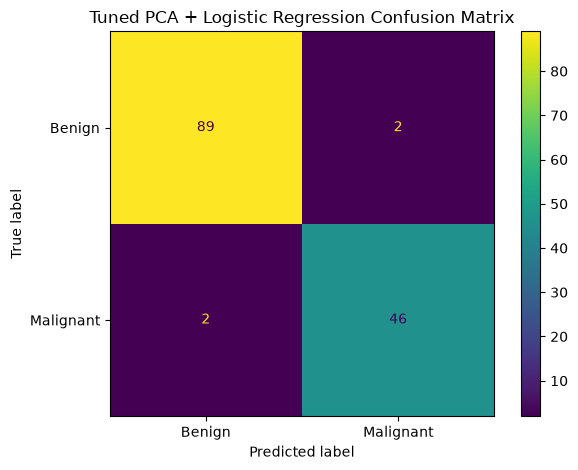

In [76]:
# ============================================================
# PLOT TUNED MODEL CONFUSION MATRIX
# ============================================================

# Create a confusion-matrix visualization for the selected
# tuned PCA + Logistic Regression model.
ConfusionMatrixDisplay(
    confusion_matrix=pca_lr_tuned_cm,
    display_labels=[
        "Benign",
        "Malignant"
    ]
).plot()


# Add a descriptive title.
plt.title(
    "Tuned PCA + Logistic Regression Confusion Matrix"
)


# Improve spacing.
plt.tight_layout()


# Display the figure.
plt.show()

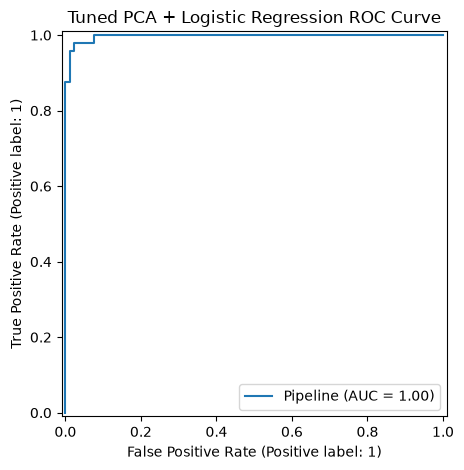

In [77]:
# ============================================================
# PLOT TUNED MODEL ROC CURVE
# ============================================================

# Create the ROC curve directly from the selected model
# and the held-out test dataset.
RocCurveDisplay.from_estimator(
    best_pca_lr_model,
    X_test,
    y_test
)


# Add a descriptive title.
plt.title(
    "Tuned PCA + Logistic Regression ROC Curve"
)


# Improve spacing.
plt.tight_layout()


# Display the graph.
plt.show()

In [78]:
# ============================================================
# CREATE BASELINE VS TUNED CROSS-VALIDATION SUMMARY
# ============================================================

# Store the mean and standard deviation of each
# cross-validation metric for both model versions.
pca_lr_cv_summary = pd.DataFrame({

    "Model": [
        "Baseline PCA + Logistic Regression",
        "Tuned PCA + Logistic Regression"
    ],

    "Accuracy_Mean": [
        pca_lr_cv_results["test_accuracy"].mean(),
        pca_lr_tuned_cv_results["test_accuracy"].mean()
    ],

    "Accuracy_STD": [
        pca_lr_cv_results["test_accuracy"].std(),
        pca_lr_tuned_cv_results["test_accuracy"].std()
    ],

    "Precision_Mean": [
        pca_lr_cv_results["test_precision"].mean(),
        pca_lr_tuned_cv_results["test_precision"].mean()
    ],

    "Precision_STD": [
        pca_lr_cv_results["test_precision"].std(),
        pca_lr_tuned_cv_results["test_precision"].std()
    ],

    "Recall_Mean": [
        pca_lr_cv_results["test_recall"].mean(),
        pca_lr_tuned_cv_results["test_recall"].mean()
    ],

    "Recall_STD": [
        pca_lr_cv_results["test_recall"].std(),
        pca_lr_tuned_cv_results["test_recall"].std()
    ],

    "F1_Mean": [
        pca_lr_cv_results["test_f1"].mean(),
        pca_lr_tuned_cv_results["test_f1"].mean()
    ],

    "F1_STD": [
        pca_lr_cv_results["test_f1"].std(),
        pca_lr_tuned_cv_results["test_f1"].std()
    ],

    "ROC_AUC_Mean": [
        pca_lr_cv_results["test_roc_auc"].mean(),
        pca_lr_tuned_cv_results["test_roc_auc"].mean()
    ],

    "ROC_AUC_STD": [
        pca_lr_cv_results["test_roc_auc"].std(),
        pca_lr_tuned_cv_results["test_roc_auc"].std()
    ]
})


print(
    "PCA + Logistic Regression Cross-Validation Summary:"
)


display(
    pca_lr_cv_summary.round(4)
)

PCA + Logistic Regression Cross-Validation Summary:


,Model,Accuracy_Mean,Accuracy_STD,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,Baseline PCA + Logistic Regression,0.9638,0.0099,0.9429,0.009,0.9526,0.0307,0.9474,0.0150,0.9948,0.0024
1,Tuned PCA + Logistic Regression,0.9692,0.0092,0.9393,0.011,0.9737,0.0288,0.9559,0.0139,0.9943,0.0020


In [79]:
# ============================================================
# SAVE MEMBER 05 FINAL-EVALUATION RESULTS
# ============================================================

# os is used to create the output directory.
import os


# Create a dedicated results folder for Member 05.
output_directory = os.path.join(
    "results",
    "member_05"
)


# Create the directory if it does not already exist.
os.makedirs(
    output_directory,
    exist_ok=True
)


# ------------------------------------------------------------
# SAVE BASELINE VS TUNED TEST RESULTS
# ------------------------------------------------------------

pca_lr_comparison.to_csv(
    os.path.join(
        output_directory,
        "pca_logistic_regression_baseline_vs_tuned.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# SAVE CROSS-VALIDATION SUMMARY
# ------------------------------------------------------------

pca_lr_cv_summary.to_csv(
    os.path.join(
        output_directory,
        "pca_logistic_regression_cross_validation_summary.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# SAVE COMPLETE GRID SEARCH RESULTS
# ------------------------------------------------------------

pca_lr_grid_results.to_csv(
    os.path.join(
        output_directory,
        "pca_logistic_regression_grid_search_results.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# SAVE TOP GRID SEARCH CONFIGURATIONS
# ------------------------------------------------------------

pca_lr_top_results.head(10).to_csv(
    os.path.join(
        output_directory,
        "pca_logistic_regression_top_configurations.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# SAVE PCA COMPONENT COMPARISON
# ------------------------------------------------------------

pca_component_comparison.to_csv(
    os.path.join(
        output_directory,
        "pca_component_comparison.csv"
    ),
    index=False
)


print(
    "Member 05 results saved successfully."
)

print(
    "Output directory:",
    output_directory
)


print("\nSaved files:")


# Display all files created in the Member 05 results folder.
for file_name in sorted(
    os.listdir(output_directory)
):

    print(
        "-",
        file_name
    )

Member 05 results saved successfully.
Output directory: results\member_05

Saved files:
- pca_component_comparison.csv
- pca_logistic_regression_baseline_vs_tuned.csv
- pca_logistic_regression_cross_validation_summary.csv
- pca_logistic_regression_grid_search_results.csv
- pca_logistic_regression_top_configurations.csv


# Member 05 – Final Conclusion

Member 05 investigated Principal Component Analysis (PCA) and developed an
individual **PCA + Logistic Regression** classification model.

The final modelling dataset contained **691 unique observations** and
**9 predictive features**. Missing values were handled using median
imputation inside the modelling pipeline.

The complete modelling pipeline was:

**Median Imputation → StandardScaler → PCA → Logistic Regression**

A stratified 80/20 train-test split produced:

- **552 training observations**
- **139 testing observations**

The baseline model reduced the original nine predictors to four principal
components. These four components retained approximately **85.55% of the
variance** in the standardized training data.

To investigate different model varieties, GridSearchCV evaluated:

- PCA component counts from **2 to 9**
- Logistic Regression C values of **0.01, 0.1, 1, 10, and 100**
- Class weighting of **None and balanced**

This produced **80 configurations** and **400 model fits** using 5-fold
stratified cross-validation.

The selected configuration was:

- **PCA components = 4**
- **C = 0.1**
- **class_weight = balanced**

It achieved a best GridSearchCV F1-score of approximately **0.9559**.

On the held-out test dataset, the selected model achieved:

- **Accuracy = 0.9712**
- **Precision = 0.9583**
- **Recall = 0.9583**
- **F1-score = 0.9583**
- **ROC-AUC = 0.9970**

The tuned model correctly identified 46 malignant observations and produced
2 false negatives.

The baseline model achieved a higher held-out test F1-score of 0.9684.
However, the tuned model was retained as the formally selected configuration
because model selection was performed using cross-validation on the training
data rather than by choosing whichever model performed best after observing
the held-out test set.

The experiment also showed that four principal components provided the
highest cross-validated F1-score among the tested PCA dimensionalities,
although several component counts produced very similar results.

Overall, PCA reduced the feature representation from nine dimensions to four
while retaining approximately 85.55% of the standardized variance and
maintaining strong classification performance.

These results are experimental and based on a relatively small historical
dataset. They should not be interpreted as evidence that the model is ready
for clinical use.